In [2]:
import heapq
import time
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Weighted graph used for BFS and A* Search

graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'D': 2, 'E': 5},
    'C': {'F': 1},
    'D': {'G': 7},
    'E': {'G': 2},
    'F': {'G': 3},
    'G': {}
}

# Heuristic values for A*
heuristic = {
    'A': 8,
    'B': 7,
    'C': 4,
    'D': 7,
    'E': 2,
    'F': 3,
    'G': 0
}

print("Graph:")
for node, neighbours in graph.items():
    print(node, "->", neighbours)

print("\nHeuristic Values:")
for node, value in heuristic.items():
    print(node, ":", value)

Graph:
A -> {'B': 1, 'C': 4}
B -> {'D': 2, 'E': 5}
C -> {'F': 1}
D -> {'G': 7}
E -> {'G': 2}
F -> {'G': 3}
G -> {}

Heuristic Values:
A : 8
B : 7
C : 4
D : 7
E : 2
F : 3
G : 0


In [4]:
# Breadth First Search

def bfs(graph, start, goal):
    queue = [[start]]
    visited = set()
    nodes_explored = 0

    while queue:
        path = queue.pop(0)
        current = path[-1]

        nodes_explored += 1

        if current == goal:
            return path, nodes_explored

        if current not in visited:
            visited.add(current)

            for neighbour in graph[current]:
                if neighbour not in visited:
                    queue.append(path + [neighbour])

    return None, nodes_explored

In [5]:
# BFS Test

start = 'A'
goal = 'G'

start_time = time.perf_counter()

bfs_path, bfs_nodes = bfs(
    graph,
    start,
    goal
)

bfs_time = time.perf_counter() - start_time

print("BFS Search")
print("-------------------------")
print("Start Node:", start)
print("Goal Node:", goal)
print("Path:", " -> ".join(bfs_path))
print("Nodes Explored:", bfs_nodes)
print("Execution Time:", bfs_time, "seconds")

BFS Search
-------------------------
Start Node: A
Goal Node: G
Path: A -> B -> D -> G
Nodes Explored: 7
Execution Time: 9.749299999839423e-05 seconds


In [6]:
# A* Search

def astar(graph, start, goal, heuristic):
    priority_queue = []

    # (f_cost, g_cost, current_node, path)
    heapq.heappush(
        priority_queue,
        (heuristic[start], 0, start, [start])
    )

    best_cost = {
        start: 0
    }

    nodes_explored = 0

    while priority_queue:

        f_cost, g_cost, current, path = heapq.heappop(
            priority_queue
        )

        nodes_explored += 1

        if current == goal:
            return path, g_cost, nodes_explored

        for neighbour, edge_cost in graph[current].items():

            new_g_cost = g_cost + edge_cost

            if (
                neighbour not in best_cost
                or new_g_cost < best_cost[neighbour]
            ):

                best_cost[neighbour] = new_g_cost

                new_f_cost = (
                    new_g_cost
                    + heuristic[neighbour]
                )

                heapq.heappush(
                    priority_queue,
                    (
                        new_f_cost,
                        new_g_cost,
                        neighbour,
                        path + [neighbour]
                    )
                )

    return None, None, nodes_explored

In [7]:
# A* Test

start = 'A'
goal = 'G'

start_time = time.perf_counter()

astar_path, astar_cost, astar_nodes = astar(
    graph,
    start,
    goal,
    heuristic
)

astar_time = time.perf_counter() - start_time

print("A* Search")
print("-------------------------")
print("Start Node:", start)
print("Goal Node:", goal)
print("Path:", " -> ".join(astar_path))
print("Path Cost:", astar_cost)
print("Nodes Explored:", astar_nodes)
print("Execution Time:", astar_time, "seconds")

A* Search
-------------------------
Start Node: A
Goal Node: G
Path: A -> C -> F -> G
Path Cost: 8
Nodes Explored: 6
Execution Time: 0.00010858400000302026 seconds


In [8]:
# Hill Climbing

def objective(x):
    return -(x - 7) ** 2 + 50


def hill_climbing(start):
    current = start
    steps = 0

    while True:

        steps += 1

        neighbours = [
            current - 1,
            current + 1
        ]

        # Remove invalid values
        neighbours = [
            x for x in neighbours
            if 0 <= x <= 15
        ]

        best_neighbour = max(
            neighbours,
            key=objective
        )

        if objective(best_neighbour) <= objective(current):
            return current, objective(current), steps

        current = best_neighbour

In [9]:
# Hill Climbing Test

initial_state = 2

start_time = time.perf_counter()

hill_solution, hill_value, hill_steps = hill_climbing(
    initial_state
)

hill_time = time.perf_counter() - start_time

print("Hill Climbing")
print("-------------------------")
print("Initial State:", initial_state)
print("Final State:", hill_solution)
print("Objective Value:", hill_value)
print("Steps:", hill_steps)
print("Execution Time:", hill_time, "seconds")

Hill Climbing
-------------------------
Initial State: 2
Final State: 7
Objective Value: 50
Steps: 6
Execution Time: 0.00010025099999211307 seconds


In [10]:
# CSP Backtracking - Map Colouring

regions = ['A', 'B', 'C', 'D']

neighbours = {
    'A': ['B', 'C'],
    'B': ['A', 'C', 'D'],
    'C': ['A', 'B', 'D'],
    'D': ['B', 'C']
}

colours = [
    'Red',
    'Green',
    'Blue'
]

csp_steps = 0


def is_valid(region, colour, assignment):

    for neighbour in neighbours[region]:

        if assignment.get(neighbour) == colour:
            return False

    return True


def solve_csp(assignment=None):

    global csp_steps

    if assignment is None:
        assignment = {}

    if len(assignment) == len(regions):
        return assignment

    region = next(
        r for r in regions
        if r not in assignment
    )

    for colour in colours:

        csp_steps += 1

        if is_valid(
            region,
            colour,
            assignment
        ):

            assignment[region] = colour

            result = solve_csp(
                assignment
            )

            if result is not None:
                return result

            del assignment[region]

    return None

In [11]:
# CSP Test

csp_steps = 0

start_time = time.perf_counter()

csp_solution = solve_csp()

csp_time = time.perf_counter() - start_time

print("CSP Backtracking - Map Colouring")
print("--------------------------------")
print("Solution:")

for region, colour in csp_solution.items():
    print(region, "=", colour)

print("Assignments / Steps:", csp_steps)
print("Execution Time:", csp_time, "seconds")

CSP Backtracking - Map Colouring
--------------------------------
Solution:
A = Red
B = Green
C = Blue
D = Red
Assignments / Steps: 7
Execution Time: 0.00011430299997527982 seconds


In [12]:
# Final Performance Comparison

results = pd.DataFrame({
    "Algorithm": [
        "BFS",
        "A*",
        "Hill Climbing",
        "CSP Backtracking"
    ],

    "Nodes / Steps": [
        bfs_nodes,
        astar_nodes,
        hill_steps,
        csp_steps
    ],

    "Execution Time (seconds)": [
        bfs_time,
        astar_time,
        hill_time,
        csp_time
    ]
})

print("FINAL PERFORMANCE COMPARISON")
print("=" * 60)

display(results)

FINAL PERFORMANCE COMPARISON


,Algorithm,Nodes / Steps,Execution Time (seconds)
0,BFS,7,0.000097
1,A*,6,0.000109
2,Hill Climbing,6,0.000100
3,CSP Backtracking,7,0.000114


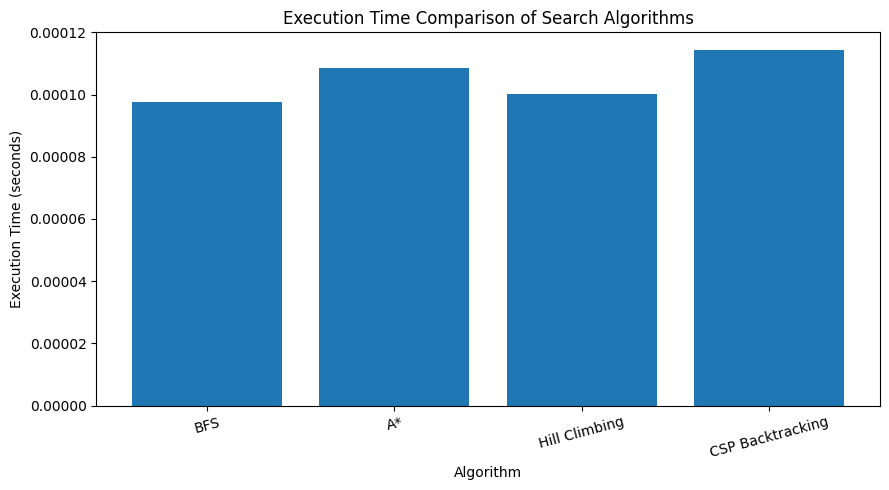

In [13]:
# Execution Time Comparison Graph

plt.figure(figsize=(9, 5))

plt.bar(
    results["Algorithm"],
    results["Execution Time (seconds)"]
)

plt.title(
    "Execution Time Comparison of Search Algorithms"
)

plt.xlabel("Algorithm")

plt.ylabel(
    "Execution Time (seconds)"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

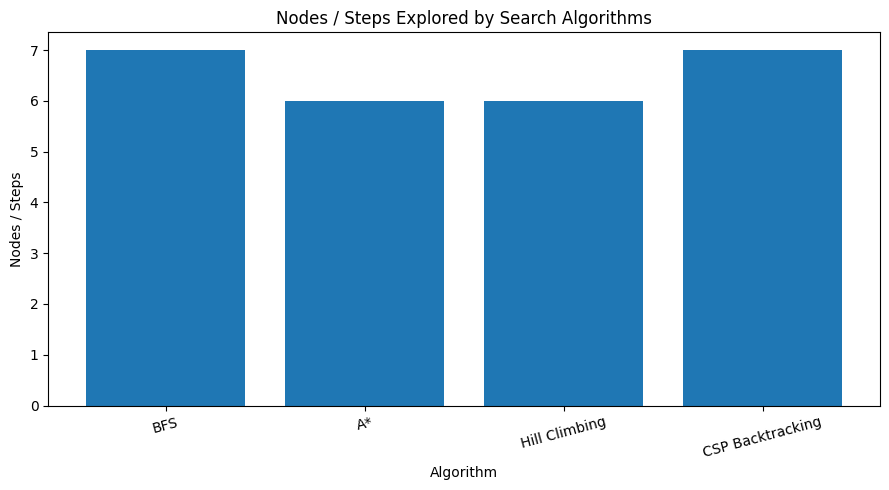

In [14]:
# Nodes / Steps Comparison

plt.figure(figsize=(9, 5))

plt.bar(
    results["Algorithm"],
    results["Nodes / Steps"]
)

plt.title(
    "Nodes / Steps Explored by Search Algorithms"
)

plt.xlabel("Algorithm")

plt.ylabel("Nodes / Steps")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [15]:
print("SEARCH ALGORITHM PERFORMANCE SUMMARY")
print("=" * 70)

for _, row in results.iterrows():

    print(
        f"{row['Algorithm']:20} | "
        f"Nodes/Steps: {row['Nodes / Steps']:3} | "
        f"Time: {row['Execution Time (seconds)']:.8f} sec"
    )

SEARCH ALGORITHM PERFORMANCE SUMMARY
BFS                  | Nodes/Steps:   7 | Time: 0.00009749 sec
A*                   | Nodes/Steps:   6 | Time: 0.00010858 sec
Hill Climbing        | Nodes/Steps:   6 | Time: 0.00010025 sec
CSP Backtracking     | Nodes/Steps:   7 | Time: 0.00011430 sec
